# Meek agrum2 vs agrum3 : la completion d'un CPDAG valide n'etait pas neutre

P est un **CPDAG valide** (squelette cordal, aucun arc contraint, aucune v-structure) :
sa classe de Markov = toutes les orientations acycliques sans collider non blinde.
Une completion correcte (`propagateToDAG`) doit rester dans cette classe, donc
**ne creer aucune v-structure nouvelle**.

Resultat : la completion d'agrum2 en cree une (`1 -> 0 <- 2` avec 1 et 2 non adjacents),
celle d'agrum3 aucune. La completion d'agrum2 n'etait pas neutre, meme sur un CPDAG valide.

- R3 agrum 2.3.0 : https://gitlab.com/agrumery/aGrUM/-/blob/2.3.0/src/agrum/base/graphs/algorithms/MeekRules.cpp#L269-280
- R3 agrum 3.0.0 : https://gitlab.com/agrumery/aGrUM/-/blob/3.0.0/src/agrum/base/graphs/algorithms/MeekRules.cpp#L274-295
- commit du changement : https://gitlab.com/agrumery/aGrUM/-/commit/13b8f2c8a87c6d87262f91bbd042b8d6c81e5188

Run All avec un kernel agrum3, puis Run All avec un kernel agrum2 ; la derniere cellule compare.

In [1]:
import json
from pathlib import Path

import pyagrum as gum
import pyagrum.lib.notebook as gnb

VERSION = f"agrum{gum.__version__.split('.')[0]}"
RESULTS = Path("/tmp/r3_meek_example")
RESULTS.mkdir(parents=True, exist_ok=True)
print(VERSION, "| pyagrum", gum.__version__)

agrum2 | pyagrum 2.3.0


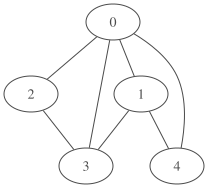

In [2]:
# P : CPDAG valide, entierement non oriente (5 noeuds, squelette cordal).
# La seule paire non adjacente est (1, 2) : la classe interdit tout collider
# x avec 1 et 2 pour parents.
EDGES = [(0, 1), (0, 2), (0, 3), (0, 4), (1, 3), (1, 4), (2, 3)]

P = gum.MixedGraph()
for i in range(5):
    P.addNodeWithId(i)
for u, v in EDGES:
    P.addEdge(u, v)
gnb.showDot(P.toDot())

In [3]:
dag = gum.MeekRules().propagateToDAG(P)

bn = gum.BayesNet()
for i in range(5):
    bn.add(gum.LabelizedVariable(f"X{i}", "", 2))
for tail, head in dag.arcs():
    bn.addArc(tail, head)
eg = gum.EssentialGraph(bn)
cpdag = eg.pdag()

(RESULTS / f"{VERSION}.json").write_text(json.dumps({
    "dag_arcs": sorted([t, h] for t, h in dag.arcs()),
    "cpdag_arcs": sorted([t, h] for t, h in cpdag.arcs()),
    "cpdag_edges": sorted([min(e), max(e)] for e in cpdag.edges()),
}))

print(VERSION, ": EssentialGraph(propagateToDAG(P)) calcule et sauvegarde")

agrum2 : EssentialGraph(propagateToDAG(P)) calcule et sauvegarde


In [4]:
versions = sorted(p.stem for p in RESULTS.glob("agrum*.json"))
assert len(versions) == 2, "lancer d'abord ce notebook dans les deux kernels (cbnsl et venv)"

P_arcs = []
P_edges = sorted([min(e), max(e)] for e in [list(e) for e in EDGES])

def pdag_from(arcs, edges):
    p = gum.PDAG()
    for i in range(5):
        p.addNodeWithId(i)
    for tail, head in arcs:
        p.addArc(tail, head)
    for u, v in edges:
        p.addEdge(u, v)
    return p

displays = [gnb.getDot(P.toDot())]
captions = ["golden CPDAG P"]
for v in versions:
    r = json.loads((RESULTS / f"{v}.json").read_text())
    neutral = (r["cpdag_arcs"] == P_arcs and r["cpdag_edges"] == P_edges)
    verdict = "NEUTRE (= P)" if neutral else "NON NEUTRE (differe de P)"
    print(f"{v} : EssentialGraph(propagateToDAG(P)) : arcs={r['cpdag_arcs']} edges={r['cpdag_edges']}  ->  {verdict}")
    displays.append(gnb.getDot(pdag_from(r["cpdag_arcs"], r["cpdag_edges"]).toDot()))
    captions.append(f"EssentialGraph(propagateToDAG(P))\n{v} — {verdict}")

gnb.sideBySide(*displays, captions=captions)

agrum2 : EssentialGraph(propagateToDAG(P)) : arcs=[[0, 4], [1, 0], [1, 4], [2, 0], [3, 0]] edges=[[1, 3], [2, 3]]  ->  NON NEUTRE (differe de P)
agrum3 : EssentialGraph(propagateToDAG(P)) : arcs=[] edges=[[0, 1], [0, 2], [0, 3], [0, 4], [1, 3], [1, 4], [2, 3]]  ->  NEUTRE (= P)


no_name <!-- 0 --> 0 0 <!-- 1 --> 1 1 <!-- 0->1 --> 0->1 <!-- 2 --> 2 2 <!-- 0->2 --> 0->2 <!-- 3 --> 3 3 <!-- 0->3 --> 0->3 <!-- 4 --> 4 4 <!-- 0->4 --> 0->4 <!-- 1->3 --> 1->3 <!-- 1->4 --> 1->4 <!-- 2->3 --> 2->3 golden CPDAG P,no_name cluster_0 <!-- 0 --> 0 0 <!-- 4 --> 4 4 <!-- 0->4 --> 0->4 <!-- 3 --> 3 3 <!-- 3->0 --> 3->0 <!-- 1 --> 1 1 <!-- 1->0 --> 1->0 <!-- 1->4 --> 1->4 <!-- 1->3 --> 1->3 <!-- 2 --> 2 2 <!-- 2->0 --> 2->0 <!-- 2->3 --> 2->3 EssentialGraph(propagateToDAG(P)) agrum2 — NON NEUTRE (differe de P),no_name cluster_0 <!-- 3 --> 3 3 <!-- 1 --> 1 1 <!-- 1->3 --> 1->3 <!-- 4 --> 4 4 <!-- 1->4 --> 1->4 <!-- 0 --> 0 0 <!-- 0->3 --> 0->3 <!-- 0->1 --> 0->1 <!-- 0->4 --> 0->4 <!-- 2 --> 2 2 <!-- 0->2 --> 0->2 <!-- 2->3 --> 2->3 EssentialGraph(propagateToDAG(P)) agrum3 — NEUTRE (= P)
